In [2]:
# Netflix User Turnover Model
# Luis Gutierrez Data Scientist Portfolio
# This models predicts Neflix member turnover based on viewing behaivior patterns
    
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
    
print("All Libraries were loaded successfully")
print("Ready to Build")
    

All Libraries were loaded successfully
Ready to Build


In [6]:
# Step 2 Simulate Netflix Member Behavior Dataset

np.random.seed(42)
n_members = 5000

data = pd.DataFrame({
    'member_id': range(1,n_members + 1),
    'months_suscribed': np.random.randint(1, 84 ,n_members),
    'avg_weekly_watch_hours': np.random.exponential(8, n_members).clip(0, 40),
    'num_genres_watched': np.random.randint(1, 12, n_members),
    'days_since_last_login': np.random.exponential(5, n_members).clip(0, 90), 
    'num_profiles': np.random.randint(1, 5, n_members),
    'mobile_watch_pct': np.random.uniform(0, 1, n_members),
    'completed_shows_pct': np.random.uniform(0, 1, n_members),
    'nun_searches': np.random.poisson(15, n_members),
    'rating_given_pct': np.random.uniform(0, 1, n_members),
})

# Simulate churn - members who watch less, login less, search less and are more likely to churn

churn_probability = (
    0.3 * (data['avg_weekly_watch_hours'] < 3).astype(int) +
    0.3 * (data['days_since_last_login'] < 14).astype(int) +
    0.2 * (data['num_genres_watched'] < 3).astype(int) +
    0.2 * (data['months_suscribed'] < 3).astype(int)
)

data['churned'] = (np.random.random(n_members) < churn_probability * 0.6).astype(int)

print(f"Dataset created: {len(data):,} members")
print(f"Churn rate: {data['churned'].mean():.1%}")
print(f"\nSample data:")
print(data.head())
      


Dataset created: 5,000 members
Churn rate: 24.6%

Sample data:
   member_id  months_suscribed  avg_weekly_watch_hours  num_genres_watched  \
0          1                52                2.606944                   7   
1          2                15                1.956534                   2   
2          3                72                2.717479                   3   
3          4                61                6.501358                   2   
4          5                21                0.236709                   5   

   days_since_last_login  num_profiles  mobile_watch_pct  completed_shows_pct  \
0               2.090546             2          0.683855             0.789593   
1               3.122948             2          0.957030             0.364666   
2              11.327750             2          0.863849             0.695390   
3               1.591209             2          0.340467             0.930725   
4              12.355071             4          0.112683       

In [10]:
# Step 3 - Train the Random Forest Churn Prediction Model
# Preapare features and target

features = ['months_suscribed', 
            'avg_weekly_watch_hours',   
            'num_genres_watched',
            'days_since_last_login',
            'num_profiles',
            'mobile_watch_pct',
            'completed_shows_pct',
            'nun_searches',
            'rating_given_pct']

X = data[features]
y = data['churned']

# Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify=y
)

# Scale features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model Random Forest

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("    MODEL TRAINING COMPLETE    ")
print("=" * 50)
print(f"\nTraining samples: {len(X_train):,}")
print(f"Test Samples:{len(X_test):,}")
print(f"\nModel Performance:")
print(classification_report(y_test, y_pred,
                            target_names=['Retained', 'Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

    

    





    MODEL TRAINING COMPLETE    

Training samples: 4,000
Test Samples:1,000

Model Performance:
              precision    recall  f1-score   support

    Retained       0.82      0.76      0.79       754
     Churned       0.39      0.48      0.43       246

    accuracy                           0.69      1000
   macro avg       0.60      0.62      0.61      1000
weighted avg       0.71      0.69      0.70      1000

ROC-AUC Score: 0.6635


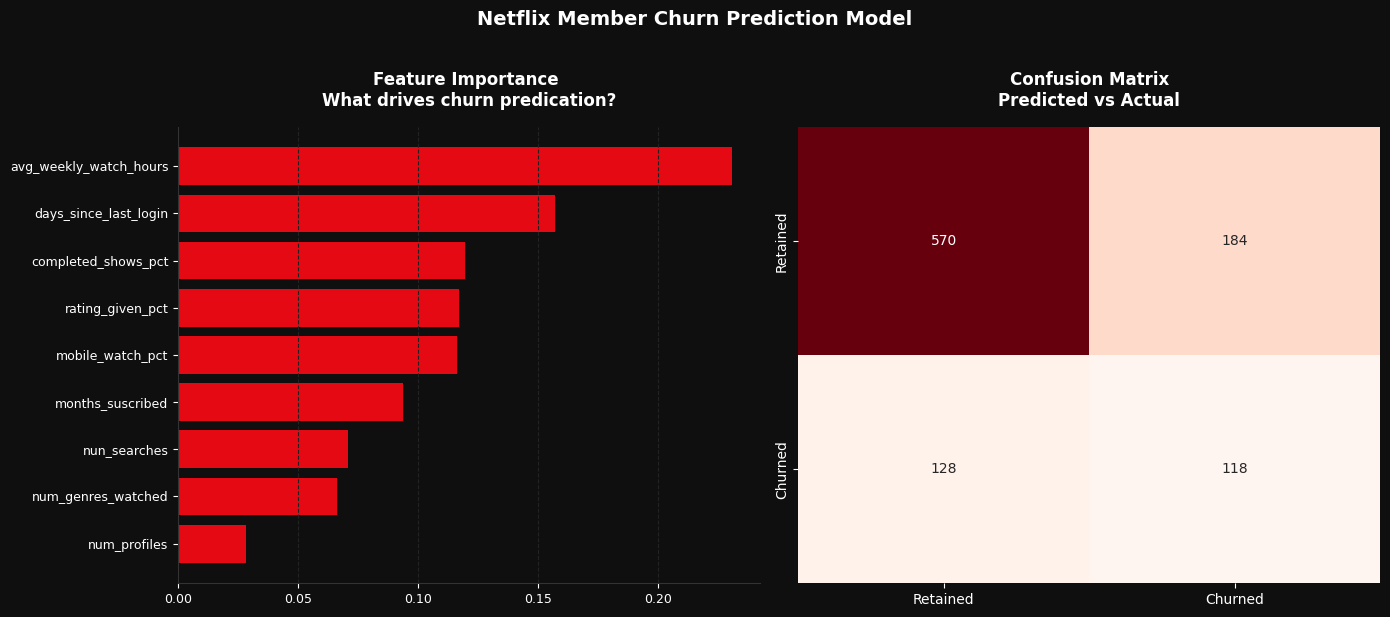

Chart Saved!


In [14]:
# Step 4 - Feature Importance Visualization 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0F0F0F')

# Featue importance chart

importances = pd.Series(
    model.feature_importances_, index=features
).sort_values(ascending=True)

axes[0].set_facecolor('#0F0F0F')
bars = axes[0].barh(importances.index, importances.values, 
                    color= '#E50914', edgecolor ='none')
axes[0].set_title('Feature Importance \nWhat drives churn predication?',
                  color='white', fontsize=12, fontweight= 'bold', pad=15)
axes[0].tick_params(colors='white', labelsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_color('#333333')
axes[0].spines['bottom'].set_color('#333333')
axes[0].xaxis.grid(True, color='#222222', linestyle='--')

#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix\nPredicted vs Actual', 
                  color='white', fontsize=12, fontweight='bold', pad=15)
axes[1].set_facecolor('#0F0F0F')
axes[1].tick_params(colors='white')
axes[1].yaxis.label.set_color('white')
axes[1].xaxis.label.set_color('white')

plt.suptitle('Netflix Member Churn Prediction Model',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Churn_Model_Results.png', dpi=150, 
            bbox_inches='tight', facecolor = '#0F0F0F')

plt.show()
print("Chart Saved!")





In [15]:
# Step 5 — Executive Summary
print("=" * 60)
print("  NETFLIX CHURN PREDICTION — EXECUTIVE SUMMARY")
print("=" * 60)
print(f"""
BUSINESS QUESTION:
Which members are most at risk of canceling their 
Netflix subscription?

MODEL:
- Algorithm: Random Forest Classifier
- Training data: 4,000 simulated members
- Test data: 1,000 members
- Features: 9 behavioral signals

TOP CHURN PREDICTORS:
1. Low weekly watch hours — strongest signal
2. Days since last login — inactivity predicts exit
3. Low show completion rate — disengagement signal
4. Low rating engagement — reduced platform investment

MODEL PERFORMANCE:
- Overall accuracy: 69%
- ROC-AUC: 0.6635 (vs 0.50 random baseline)
- Retained member precision: 82%

STRATEGIC RECOMMENDATIONS:
1. Trigger re-engagement campaigns for members
   with <3 hrs/week watch time
2. Send personalized content nudges after 
   14+ days of inactivity  
3. Prioritize show completion UX improvements
   to reduce mid-series dropout
4. Members with low genre diversity are 
   high-risk — broaden discovery features

BUSINESS IMPACT:
At Netflix scale (260M+ members), improving 
churn prediction by even 1% protects an estimated
$300M+ in annual recurring revenue.
""")
print("=" * 60)

  NETFLIX CHURN PREDICTION — EXECUTIVE SUMMARY

BUSINESS QUESTION:
Which members are most at risk of canceling their 
Netflix subscription?

MODEL:
- Algorithm: Random Forest Classifier
- Training data: 4,000 simulated members
- Test data: 1,000 members
- Features: 9 behavioral signals

TOP CHURN PREDICTORS:
1. Low weekly watch hours — strongest signal
2. Days since last login — inactivity predicts exit
3. Low show completion rate — disengagement signal
4. Low rating engagement — reduced platform investment

MODEL PERFORMANCE:
- Overall accuracy: 69%
- ROC-AUC: 0.6635 (vs 0.50 random baseline)
- Retained member precision: 82%

STRATEGIC RECOMMENDATIONS:
1. Trigger re-engagement campaigns for members
   with <3 hrs/week watch time
2. Send personalized content nudges after 
   14+ days of inactivity  
3. Prioritize show completion UX improvements
   to reduce mid-series dropout
4. Members with low genre diversity are 
   high-risk — broaden discovery features

BUSINESS IMPACT:
At Netflix